### <u><B> *HIERARCHICAL CLUSTERING*</B></U>

hierarchical clustering is an unsupervised learning technique that:
 
- groups data step by step
- creates a tree-like structure called a dendrogram
- does not require you to choose K beforehand

TYPES:

-> AGGLOMERATIVE (Bottom up)

-> DIVISIVE (Top down)

#### AGGLOMERATIVE HIERARCHICAL CLUSTERING
STEPS: 

- Treat each data point as its own cluster

- Compute distance matrix

- Merge the two closest clusters

- Recompute distances

- Repeat until one cluster remains

The entire history of merges is saved → dendrogram

<img src= "agglomerative_dendrogram.png" width=400/>

LINKAGE CRITERIAS IN AGGLOMERATIVE CLUSTERING:

1. Single linkage (MIN distance)

2. Complete linkage (MAX distance)

3. Average linkage 

4. Ward's linkage 
- uses euclidean distance

##### Ward’s Linkage (Minimum Variance Method)

Ward’s method merges clusters that cause the minimum increase in within-cluster variance:

$$
\Delta(A, B)
=
\sum_{x \in A \cup B} \|x - \mu_{A \cup B}\|^2
-
\left(
\sum_{x \in A} \|x - \mu_A\|^2
+
\sum_{x \in B} \|x - \mu_B\|^2
\right)
$$

Where:

- $A, B$ : Two clusters
- $\mu_A, \mu_B$ : Centroids of clusters A and B
- $\mu_{A \cup B}$ : Centroid after merging
- $\sum \|x - \mu\|^2$ : Within-cluster Sum of Squared Errors (SSE)
- $\Delta(A,B)$ : Increase in variance after merging



To find out the number of clusters to be there in the hierarchical clustering , we use dendrogram here , likewise we used elbow method in k means

hyperparameters in agglomerative clustering:

- n_clusters
- affinity (euclidian by default)
- distance_threshold

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:

np.random.seed(42)

n_rows = 160

data = {
    "CustomerID": np.arange(1, n_rows + 1),
    "Genre": np.random.choice(["Male", "Female"], size=n_rows),
    "Age": np.random.randint(18, 70, size=n_rows),
    "Annual Income (k$)": np.random.randint(15, 140, size=n_rows),
    "Spending Score (1-100)": np.random.randint(1, 101, size=n_rows)
}

df = pd.DataFrame(data)
df


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,24,64,9
1,2,Female,26,37,43
2,3,Male,25,45,48
3,4,Male,29,108,39
4,5,Male,51,56,93
...,...,...,...,...,...
155,156,Female,57,16,43
156,157,Male,18,104,44
157,158,Female,28,31,29
158,159,Male,45,118,13


In [5]:
data = df.iloc[: ,3:5].values
data

array([[ 64,   9],
       [ 37,  43],
       [ 45,  48],
       [108,  39],
       [ 56,  93],
       [113,  42],
       [ 21,  26],
       [138,  99],
       [ 30,  50],
       [104,  25],
       [126,  24],
       [135,  13],
       [130,  60],
       [ 74,   7],
       [127,  57],
       [ 16,  36],
       [ 15,  45],
       [ 62,  20],
       [ 26,  65],
       [ 83,   8],
       [ 51,  16],
       [ 46,  14],
       [137,  76],
       [133,  87],
       [ 23,  15],
       [119,  92],
       [113,  98],
       [ 33,  66],
       [ 62,  32],
       [ 94,  87],
       [ 17,  63],
       [ 34,  86],
       [ 38,  51],
       [ 68,  25],
       [134,  58],
       [ 47,  63],
       [ 38,  62],
       [130,  22],
       [ 89,  58],
       [127,  58],
       [ 86,  86],
       [ 50,  49],
       [ 52,  52],
       [118,  42],
       [ 98,  70],
       [113,  15],
       [126,  54],
       [103,  60],
       [113,  97],
       [ 39,   8],
       [107,  53],
       [ 32,  60],
       [124,

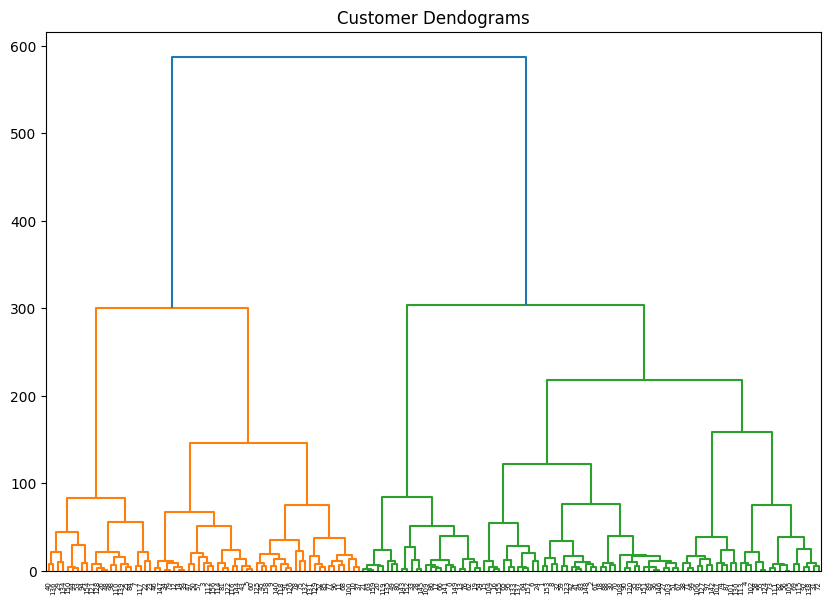

In [6]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))
plt.title("Customer Dendograms")
dend = shc.dendrogram(shc.linkage(data,method='ward'))

In [8]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

X= df.iloc[:,3:5]
X_scaled=scaler.fit_transform(X)


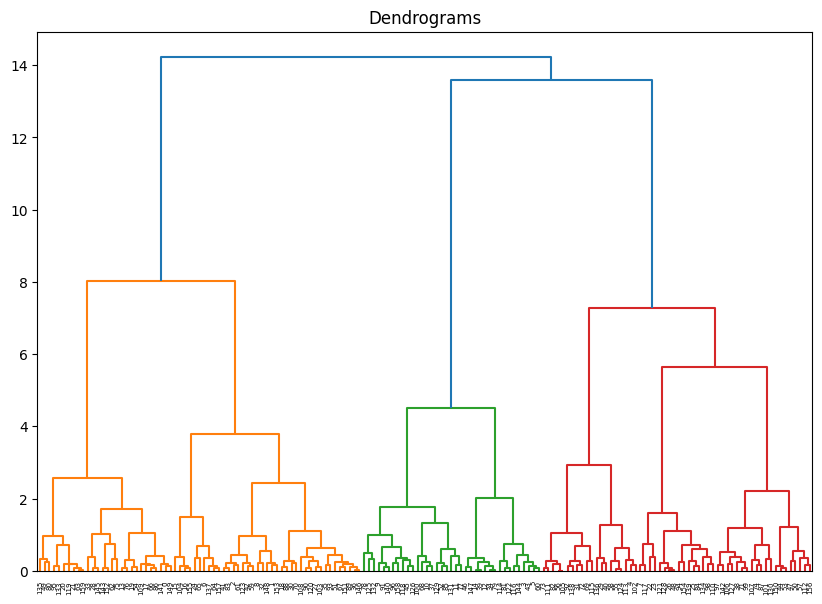

In [9]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X_scaled,method='ward'))
plt.show()

In [25]:
from sklearn.cluster import AgglomerativeClustering

cluster=AgglomerativeClustering(n_clusters=4,linkage='ward')

df['cluster']= cluster.fit_predict(X_scaled)
df['cluster']

0      3
1      1
2      1
3      2
4      0
      ..
155    1
156    0
157    1
158    2
159    3
Name: cluster, Length: 160, dtype: int64

In [26]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,24,64,9,3
1,2,Female,26,37,43,1
2,3,Male,25,45,48,1
3,4,Male,29,108,39,2
4,5,Male,51,56,93,0


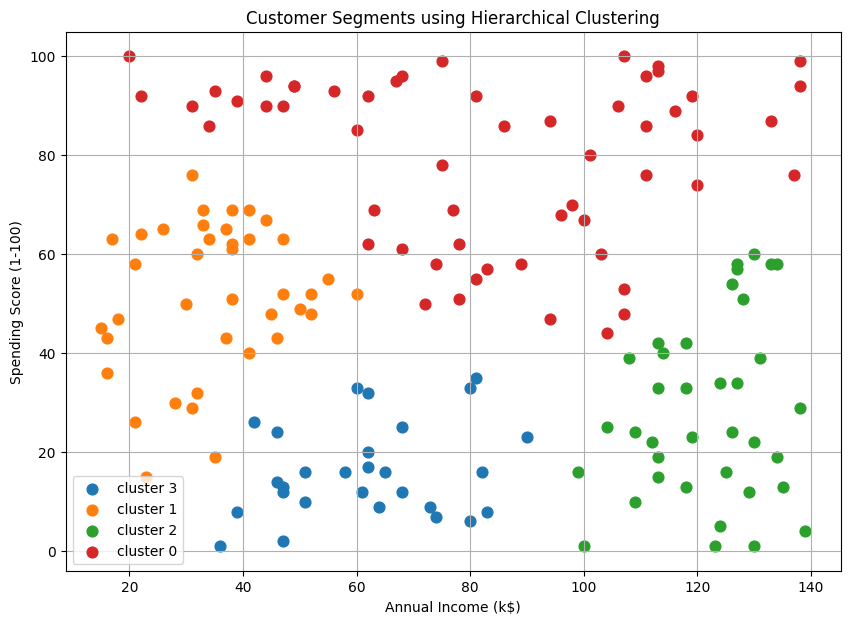

In [27]:
plt.figure(figsize=(10,7))
for clr in df['cluster'].unique():
    plt.scatter(
        df[df['cluster'] == clr]['Annual Income (k$)'],
        df[df['cluster'] == clr]['Spending Score (1-100)'],
        label=f'cluster {clr}',
        s=60
    )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using Hierarchical Clustering")
plt.legend()
plt.grid(True)
plt.show()

benefits of hierarchical clustering:

- no need to pre-define number of clusters
- Widely applicable
- n assumption about cluster shape
- works well for small and medium dataset